# Data Sanity Checks & Imputation — From Raw Data to Analysis-Ready

**Course:** Practical Data Cleaning in Python
**Level:** Basic → Intermediate

Before *any* analysis — a model, a chart, a KPI — the data has to be trustworthy.
"Garbage in, garbage out" is the whole reason this step exists. In this notebook we take
one deliberately messy dataset and walk it through **every stage** until it is clean and
ready for analysis.

### The pipeline we will follow
1. **Pull / load** the data
2. **First look** — structural sanity checks (shape, types, sample, summary)
3. **Standardise column names**
4. **Fix data types** (text that should be numbers / dates)
5. **Handle duplicates**
6. **Standardise text & categories** (case, spelling, whitespace)
7. **Validity, range & logical checks** (impossible values → mark as missing)
8. **Missing-value analysis** (how much, where, what pattern)
9. **Outlier detection** (IQR method)
10. **Imputation** (fill missing values sensibly)
11. **Final validation** (prove the data is clean)
12. **Export** the analysis-ready dataset

> **The mental model:** *first make every value the right **type**, then find every value
> that is **wrong or missing**, then **fix** it, then **prove** you fixed it.*

The dataset (`employee_data_raw.xlsx`) is a small HR table of 50 employees that we have
intentionally corrupted with real-world problems so we can practise fixing them. Keep this
file in the same folder as the notebook and **run the cells top to bottom.**


## 1. Pull / load the data

In the real world your data arrives from a **database (SQL), an API, a CSV, an Excel export,
or a data warehouse**. The pattern is always the same afterwards, so here we load from Excel.

Load once, then transform progressively — each step reassigns `df`.

In [1]:
import pandas as pd
import numpy as np

# In practice this might be pd.read_sql(...), pd.read_csv(...), an API call, etc.
df = pd.read_excel("employee_data_raw.xlsx", sheet_name="employees")

# Keep a copy of the raw data so we can compare 'before vs after' later.
df_raw = df.copy()

print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (50, 10)


,Employee ID,Full Name,Age,Gender,Department,Join Date,Salary,Experience_Years,City,Performance Score
0,1001,Aarav Sharma,26.0,F,Finance,2017-11-02,158000,6.0,Delhi,2.0
1,1002,Diya Iyer,50.0,M,sales,15/03/2018,72000,27.0,Bangalore,5.0
2,1003,Rohan Mehta,45.0,Male,Finance,2015-04-10,"$95,000",15.0,Delhi,1.0
3,1004,Sara Khan,38.0,M,Sales,2016-10-06,NaN,18.0,mumbai,5.0
4,1005,Vikram Singh,NaN,M,MARKETING,2022-08-13,95000,14.0,Pune,3.0


## 2. First look — structural sanity checks

Never start cleaning blindly. First *understand the shape of the problem*. Four questions:

- **How big is it?** `.shape`
- **What do rows look like?** `.head()`, `.tail()`, `.sample()`
- **What are the types and how many nulls?** `.info()`
- **What do the values look like numerically & categorically?** `.describe()`

Look for red flags: columns that *should* be numeric but show up as `object`, suspicious
min/max values, unexpected null counts.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee ID        50 non-null     int64  
 1   Full Name          50 non-null     str    
 2   Age                47 non-null     float64
 3   Gender             49 non-null     str    
 4   Department         48 non-null     str    
 5   Join Date          49 non-null     str    
 6   Salary             47 non-null     object 
 7   Experience_Years   48 non-null     float64
 8   City               48 non-null     str    
 9   Performance Score  48 non-null     float64
dtypes: float64(3), int64(1), object(1), str(5)
memory usage: 4.0+ KB


In [3]:
# A random sample often reveals messiness that head()/tail() hide
df.sample(8, random_state=1)

,Employee ID,Full Name,Age,Gender,Department,Join Date,Salary,Experience_Years,City,Performance Score
27,1028,KARAN SINGH,51.0,M,HR,2020-03-06,54000,17.0,Chennai,1.0
35,1036,Sneha Rao,200.0,F,Marketing,2013-05-06,96000,5.0,Hyderabad,5.0
40,1041,Harsh Sharma,28.0,M,Finance,2020-03-05,132000,5.0,NaN,4.0
38,1039,Om Bose,32.0,F,Marketing,2021-10-07,65000,9.0,Pune,9.0
2,1003,Rohan Mehta,45.0,Male,Finance,2015-04-10,"$95,000",15.0,Delhi,1.0
3,1004,Sara Khan,38.0,M,Sales,2016-10-06,NaN,18.0,mumbai,5.0
48,1049,Naveen Bose,46.0,F,Finance,2015-01-27,80000,23.0,Delhi,1.0
29,1030,Simran Gupta,38.0,F,HR,NaN,105000,6.0,Mumbai,3.0


In [4]:
# include='all' -> summary for BOTH numeric and text columns
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee ID,50.0,NaN,NaN,NaN,1024.82,14.848473,1001.0,1012.25,1024.5,1037.75,1049.0
Full Name,50,49,Naveen Bose,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,47.0,NaN,NaN,NaN,44.744681,25.736514,0.0,34.5,45.0,50.0,200.0
Gender,49,8,F,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,48,10,Engineering,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Join Date,49,48,2015-01-27,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,47.0,39.0,80000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience_Years,48.0,NaN,NaN,NaN,13.125,8.770417,-3.0,6.0,14.0,18.0,45.0
City,48,10,Delhi,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance Score,48.0,NaN,NaN,NaN,3.145833,1.774399,0.0,2.0,3.0,5.0,9.0


**What the first look already tells us**

- `Salary` is stored as **object** (text), not a number → something non-numeric is inside it.
- `Join Date` is text, not a real date.
- Column names are inconsistent: some have spaces (`Employee ID`), one uses an underscore
  (`Experience_Years`).
- `Age` has a **max of 200** and a **min of 0** — both impossible for an employee.
- Several columns already show missing values.

We now fix these one category at a time.

## 3. Standardise column names

Messy column names (`"Employee ID"`, `"Performance Score"`) force you to type quotes and
brackets everywhere and cause silent typos. Standardise to **lowercase, no spaces,
underscores** — a clean, predictable convention.

In [5]:
print("Before:", list(df.columns))

df.columns = (df.columns
              .str.strip()            # remove stray spaces
              .str.lower()            # lowercase
              .str.replace(" ", "_", regex=False))  # spaces -> underscores

print("After :", list(df.columns))

Before: ['Employee ID', 'Full Name', 'Age', 'Gender', 'Department', 'Join Date', 'Salary', 'Experience_Years', 'City', 'Performance Score']
After : ['employee_id', 'full_name', 'age', 'gender', 'department', 'join_date', 'salary', 'experience_years', 'city', 'performance_score']


## 4. Fix data types

Types are the foundation. You cannot compute a mean on text, or sort dates that are strings.

### 4a. `salary` — text with currency symbols and commas
Let's see *why* pandas refused to read it as a number.

In [6]:
# The offending values: $ signs, thousands separators, plain numeric strings, NaN
df["salary"].head(8).tolist()

[158000, 72000, '$95,000', nan, 95000, 129000, '1,20,000', 113000]

In [7]:
def clean_salary(x):
    """Strip $ and commas, convert to float. Anything unconvertible -> NaN."""
    if pd.isna(x):
        return np.nan
    s = str(x).replace("$", "").replace(",", "").strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

df["salary"] = df["salary"].apply(clean_salary)
print("salary dtype is now:", df["salary"].dtype)
df["salary"].head(8).tolist()

salary dtype is now: float64


[158000.0, 72000.0, 95000.0, nan, 95000.0, 129000.0, 120000.0, 113000.0]

### 4b. `join_date` — text in mixed formats

Some dates are `YYYY-MM-DD`, some are `DD/MM/YYYY`, and one literally says *"not available"*.
`pd.to_datetime` with **`errors="coerce"`** turns anything unparseable into `NaT`
(the datetime version of NaN) instead of crashing.

In [8]:
df["join_date"] = pd.to_datetime(
    df["join_date"],
    format="mixed",     # allow different date formats in the same column
    dayfirst=True,      # treat 15/03/2018 as 15 March, not month 15
    errors="coerce",    # unparseable -> NaT instead of an error
)
print("join_date dtype:", df["join_date"].dtype)
print("Unparseable dates (NaT):", df["join_date"].isna().sum())

join_date dtype: datetime64[us]
Unparseable dates (NaT): 2


### 4c. Make sure the remaining numeric columns really are numeric
A cheap insurance step: `to_numeric(..., errors='coerce')`.

In [9]:
for c in ["age", "experience_years", "performance_score"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.dtypes

employee_id                   int64
full_name                       str
age                         float64
gender                          str
department                      str
join_date            datetime64[us]
salary                      float64
experience_years            float64
city                            str
performance_score           float64
dtype: object

## 5. Handle duplicates

Two kinds of duplicates:

1. **Full duplicate rows** — every column identical. Almost always safe to drop.
2. **Duplicate keys** — the same `employee_id` on different rows. A business rule violation
   (an ID should be unique). We keep the first occurrence here; in a real project you would
   investigate *why* it happened.

In [10]:
# 1) Fully duplicated rows
print("Fully duplicated rows:", df.duplicated().sum())
df[df.duplicated(keep=False)]   # keep=False shows ALL copies, not just the extras

Fully duplicated rows: 1


,employee_id,full_name,age,gender,department,join_date,salary,experience_years,city,performance_score
48,1049,Naveen Bose,46.0,F,Finance,2015-01-27,80000.0,23.0,Delhi,1.0
49,1049,Naveen Bose,46.0,F,Finance,2015-01-27,80000.0,23.0,Delhi,1.0


In [11]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping full duplicates:", df.shape)

Shape after dropping full duplicates: (49, 10)


In [12]:
# 2) Duplicate primary keys (employee_id must be unique)
print("Duplicate employee_id values:", df["employee_id"].duplicated().sum())
df[df["employee_id"].duplicated(keep=False)].sort_values("employee_id")

Duplicate employee_id values: 1


,employee_id,full_name,age,gender,department,join_date,salary,experience_years,city,performance_score
1,1002,Diya Iyer,50.0,M,sales,2018-03-15,72000.0,27.0,Bangalore,5.0
34,1002,Rehan Singh,54.0,F,HR,2012-07-05,104000.0,15.0,Bangalore,3.0


In [13]:
df = df.drop_duplicates(subset="employee_id", keep="first").reset_index(drop=True)
print("Shape after enforcing unique employee_id:", df.shape)

Shape after enforcing unique employee_id: (48, 10)


## 6. Standardise text & categories

Humans type `"Male"`, `"male "`, `"m"`, `"MALE"` and mean the same thing. To a computer
these are four different categories. Standardise **whitespace**, **case**, and **spelling**
so each real category is a single label.

The recipe: `.str.strip()` → `.str.lower()`/`.str.title()` → `.map()`/`.replace()` for the
remaining spelling variants.

In [14]:
print("gender - before:", df["gender"].dropna().unique())

gender_map = {"m": "Male", "male": "Male", "f": "Female", "female": "Female"}
df["gender"] = df["gender"].str.strip().str.lower().map(gender_map)

print("gender - after :", df["gender"].dropna().unique())

gender - before: <StringArray>
['F', 'M', 'Male', 'female', 'male ', 'F ', 'm', 'FEMALE']
Length: 8, dtype: str
gender - after : <StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [15]:
print("department - before:", df["department"].dropna().unique())

# Title-case fixes case AND whitespace; then map alternate spellings to the canonical label
df["department"] = df["department"].str.strip().str.title()
df["department"] = df["department"].replace({"Human Resources": "HR", "Hr": "HR"})

print("department - after :", df["department"].dropna().unique())

department - before: <StringArray>
[        'Finance',           'sales',           'Sales',       'MARKETING',
              'HR', 'Human Resources',     'Engineering',   '  Engineering',
         'finance',       'Marketing']
Length: 10, dtype: str
department - after : <StringArray>
['Finance', 'Sales', 'Marketing', 'HR', 'Engineering']
Length: 5, dtype: str


In [16]:
# City: whitespace + case only
df["city"] = df["city"].str.strip().str.title()
# Names: tidy for display
df["full_name"] = df["full_name"].str.strip().str.title()

print("city - after:", df["city"].dropna().unique())
df[["full_name", "gender", "department", "city"]].head()

city - after: <StringArray>
['Delhi', 'Bangalore', 'Mumbai', 'Pune', 'Chennai', 'Hyderabad']
Length: 6, dtype: str


,full_name,gender,department,city
0,Aarav Sharma,Female,Finance,Delhi
1,Diya Iyer,Male,Sales,Bangalore
2,Rohan Mehta,Male,Finance,Delhi
3,Sara Khan,Male,Sales,Mumbai
4,Vikram Singh,Male,Marketing,Pune


## 7. Validity, range & logical checks (the heart of the *sanity check*)

Now that types and labels are clean, hunt for values that are **the right type but wrong in
reality**. Use **domain knowledge** to define what is possible:

| Field | Rule | Action if broken |
|---|---|---|
| age | between 18 and 70 | set to `NaN` |
| salary | must be ≥ 0 | set to `NaN` |
| experience_years | must be ≥ 0 | set to `NaN` |
| experience_years | cannot exceed `age - 15` | set to `NaN` (started work before age 15?) |
| performance_score | between 1 and 5 | set to `NaN` |

We convert impossible values to `NaN` rather than deleting rows — that way the *rest* of the
row's good data is preserved, and imputation (Step 10) can fill the hole sensibly.

In [17]:
# See the impossible values before we act
print("Ages outside 18-70 :", df.loc[(df.age < 18) | (df.age > 70), "age"].tolist())
print("Negative salaries  :", df.loc[df.salary < 0, "salary"].tolist())
print("Negative experience:", df.loc[df.experience_years < 0, "experience_years"].tolist())
print("Scores outside 1-5 :",
      df.loc[(df.performance_score < 1) | (df.performance_score > 5),
             "performance_score"].tolist())
# Logical cross-field check: more experience than plausibly possible for the age
mask_logic = df["experience_years"] > (df["age"] - 15)
print("Experience > (age - 15):")
print(df.loc[mask_logic, ["employee_id", "age", "experience_years"]])

Ages outside 18-70 : [0.0, 200.0]
Negative salaries  : [-50000.0]
Negative experience: [-3.0]
Scores outside 1-5 : [9.0, 0.0]
Experience > (age - 15):
    employee_id   age  experience_years
21         1022   0.0              14.0
31         1032  30.0              45.0


In [18]:
# Apply the rules: impossible -> NaN
df.loc[(df.age < 18) | (df.age > 70), "age"] = np.nan
df.loc[df.salary < 0, "salary"] = np.nan
df.loc[df.experience_years < 0, "experience_years"] = np.nan
df.loc[df.experience_years > (df.age - 15), "experience_years"] = np.nan
df.loc[(df.performance_score < 1) | (df.performance_score > 5),
       "performance_score"] = np.nan

print("Done. These impossible values are now marked missing (NaN).")

Done. These impossible values are now marked missing (NaN).


## 8. Missing-value analysis

Before filling anything, *understand* the missingness: **how much**, **where**, and ideally
**why**. A quick count + percentage table is the standard first move.

**Three broad patterns (good to know the vocabulary):**
- **MCAR** — Missing Completely At Random (a sensor randomly failed). Simple imputation is safe.
- **MAR** — Missing At Random, i.e. related to *other observed* columns (older employees skip
  the salary field). Group-based imputation helps.
- **MNAR** — Missing Not At Random, related to the *missing value itself* (very high earners
  hide salary). The hardest case — imputation can bias results, so flag it.

In [19]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(1),
}).sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
age,5,10.4
performance_score,4,8.3
experience_years,4,8.3
salary,4,8.3
department,2,4.2
join_date,2,4.2
city,2,4.2
gender,1,2.1
full_name,0,0.0
employee_id,0,0.0


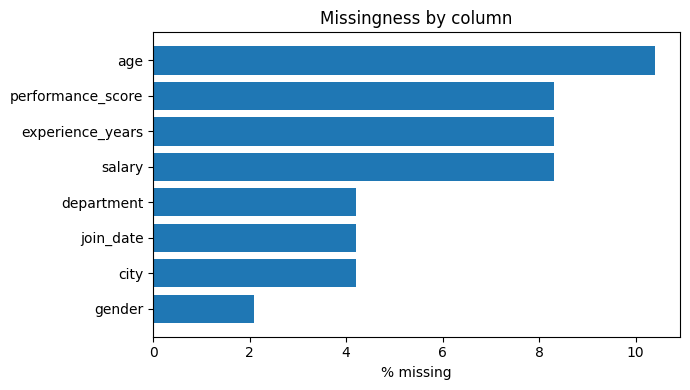

In [20]:
import matplotlib.pyplot as plt

miss = missing[missing["missing_count"] > 0]
plt.figure(figsize=(7, 4))
plt.barh(miss.index, miss["missing_pct"])
plt.xlabel("% missing")
plt.title("Missingness by column")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Outlier detection (IQR method)

An **outlier** is a value far from the rest of the data. It can be a genuine extreme, or a
data-entry error. A robust, distribution-free way to flag them is the **Interquartile Range
(IQR)** rule:

- `Q1` = 25th percentile, `Q3` = 75th percentile, `IQR = Q3 − Q1`
- Anything below `Q1 − 1.5·IQR` or above `Q3 + 1.5·IQR` is flagged.

We check `salary`. Options for a real outlier: **remove**, **cap (winsorise)**, or **keep &
document**. Here we **cap** the upper tail so one absurd value can't distort a mean or a model.

In [21]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low, high = iqr_bounds(df["salary"])
print(f"Acceptable salary range: {low:,.0f} to {high:,.0f}")
print("Flagged outliers:",
      df.loc[(df.salary < low) | (df.salary > high), "salary"].tolist())

Acceptable salary range: -11,250 to 218,750
Flagged outliers: [9999999.0]


In [22]:
# Cap (winsorise) the upper tail at the IQR boundary
df["salary"] = df["salary"].clip(lower=max(low, 0), upper=high)
print("Max salary after capping:", df["salary"].max())

Max salary after capping: 218750.0


## 10. Imputation — filling the missing values

Now we fill the holes (both original blanks and the impossible values we converted to `NaN`).
Choosing *how* matters:

**Numeric columns**
- **Mean** — simple, but dragged around by outliers.
- **Median** — robust to outliers. **Good default** for skewed data like salary. ✅
- **Group-based** — fill using the median *within a relevant group* (e.g. salary median *per
  department*). Usually the most accurate because it respects real structure.

**Categorical columns**
- **Mode** (most frequent value), or an explicit `"Unknown"` category.

**Dates** — usually **do not invent** dates. We leave unparseable `join_date` as `NaT` and
flag those rows instead.

> Rule of thumb: prefer **median** over mean for money/skewed numbers, and use **group-based**
> imputation whenever a sensible grouping column exists.

In [23]:
# --- Numeric: median for age, experience, performance ---
df["age"] = df["age"].fillna(df["age"].median())
df["experience_years"] = df["experience_years"].fillna(df["experience_years"].median())
df["performance_score"] = df["performance_score"].fillna(df["performance_score"].median())

# --- Salary: GROUP-BASED (median salary within each department) ---
salary_by_dept = df.groupby("department")["salary"].transform("median")
df["salary"] = df["salary"].fillna(salary_by_dept)
# Safety net: if a whole department was missing, fall back to the global median
df["salary"] = df["salary"].fillna(df["salary"].median())

# --- Categorical: mode (most common value) ---
for c in ["gender", "department", "city"]:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

print("Remaining missing values per column:")
print(df.isna().sum())

Remaining missing values per column:
employee_id          0
full_name            0
age                  0
gender               0
department           0
join_date            2
salary               0
experience_years     0
city                 0
performance_score    0
dtype: int64


### (Optional, advanced) Model-based imputation with scikit-learn

For a stronger fill you can use **KNN imputation**, which estimates a missing value from the
most similar rows across several numeric columns at once. This needs `scikit-learn`; the cell
degrades gracefully if it isn't installed. (Below is illustrative — our data is already
imputed above, so this is just to show the API.)

In [24]:
try:
    from sklearn.impute import KNNImputer
    num_cols = ["age", "salary", "experience_years", "performance_score"]
    knn = KNNImputer(n_neighbors=3)
    example = pd.DataFrame(knn.fit_transform(df[num_cols]), columns=num_cols)
    print("KNNImputer ran. Example output (first 3 rows):")
    print(example.head(3))
except ModuleNotFoundError:
    print("scikit-learn not installed - skipping the optional KNN demo.")
    print("Install with:  pip install scikit-learn")

KNNImputer ran. Example output (first 3 rows):
    age    salary  experience_years  performance_score
0  26.0  158000.0               6.0                2.0
1  50.0   72000.0              27.0                5.0
2  45.0   95000.0              15.0                1.0


## 11. Final validation — *prove* the data is clean

Cleaning isn't finished until you can demonstrate it. Re-run the sanity checks and confirm:

- correct **dtypes**
- **no unexpected missing values** (only the deliberately-flagged `join_date` NaTs remain)
- values are within **valid ranges**
- **logical rules** hold

In [25]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values remaining:\n", df.isna().sum())

Shape: (48, 10)

Dtypes:
 employee_id                   int64
full_name                       str
age                         float64
gender                          str
department                      str
join_date            datetime64[us]
salary                      float64
experience_years            float64
city                            str
performance_score           float64
dtype: object

Missing values remaining:
 employee_id          0
full_name            0
age                  0
gender               0
department           0
join_date            2
salary               0
experience_years     0
city                 0
performance_score    0
dtype: int64


In [26]:
# Re-run the range & logic checks - all should be 0
checks = {
    "age out of 18-70": ((df.age < 18) | (df.age > 70)).sum(),
    "negative salary": (df.salary < 0).sum(),
    "negative experience": (df.experience_years < 0).sum(),
    "experience > age-15": (df.experience_years > (df.age - 15)).sum(),
    "score out of 1-5": ((df.performance_score < 1) | (df.performance_score > 5)).sum(),
    "duplicate ids": df["employee_id"].duplicated().sum(),
}
for k, v in checks.items():
    print(f"{'PASS' if v == 0 else 'FAIL'}  {k}: {v}")

PASS  age out of 18-70: 0
PASS  negative salary: 0
PASS  negative experience: 0
PASS  experience > age-15: 0
PASS  score out of 1-5: 0
PASS  duplicate ids: 0


In [27]:
# Before vs after, at a glance
print("RAW   :", df_raw.shape, "| total missing:", int(df_raw.isna().sum().sum()))
print("CLEAN :", df.shape, "| total missing:", int(df.isna().sum().sum()),
      "(the remaining ones are the unparseable join dates we chose to keep as NaT)")
df.describe(include="all").T

RAW   : (50, 10) | total missing: 16
CLEAN : (48, 10) | total missing: 2 (the remaining ones are the unparseable join dates we chose to keep as NaT)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
employee_id,48.0,NaN,NaN,NaN,1024.791667,1001.0,1012.75,1024.5,1037.25,1049.0,14.364493
full_name,48,48,Aarav Sharma,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,48.0,NaN,NaN,NaN,42.25,25.0,36.5,45.0,49.25,57.0,9.198751
gender,48,2,Male,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,48,5,Engineering,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
join_date,46,NaN,NaN,NaN,2017-10-04 02:36:31.304347,2012-01-22 00:00:00,2014-12-19 00:00:00,2017-04-16 00:00:00,2021-01-23 00:00:00,2022-11-13 00:00:00,NaN
salary,48.0,NaN,NaN,NaN,101869.791667,33000.0,77250.0,95000.0,129750.0,218750.0,40535.313918
experience_years,48.0,NaN,NaN,NaN,12.583333,1.0,6.0,13.5,17.25,27.0,6.879922
city,48,6,Bangalore,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_score,48.0,NaN,NaN,NaN,3.125,1.0,2.0,3.0,4.25,5.0,1.45317


## 12. Export the analysis-ready dataset

Save the cleaned data so downstream analysis / modelling starts from a trustworthy file.

In [28]:
df.to_excel("employee_data_clean.xlsx", index=False, sheet_name="employees_clean")
print("Saved -> employee_data_clean.xlsx")
df.head()

Saved -> employee_data_clean.xlsx


,employee_id,full_name,age,gender,department,join_date,salary,experience_years,city,performance_score
0,1001,Aarav Sharma,26.0,Female,Finance,2017-02-11,158000.0,6.0,Delhi,2.0
1,1002,Diya Iyer,50.0,Male,Sales,2018-03-15,72000.0,27.0,Bangalore,5.0
2,1003,Rohan Mehta,45.0,Male,Finance,2015-10-04,95000.0,15.0,Delhi,1.0
3,1004,Sara Khan,38.0,Male,Sales,2016-06-10,79500.0,18.0,Mumbai,5.0
4,1005,Vikram Singh,45.0,Male,Marketing,2022-08-13,95000.0,14.0,Pune,3.0


## 13. Combining datasets — concatenate & merge

Real analyses rarely fit in one table. Two core operations bring data together:

- **Concatenate** (`pd.concat`) — **stack** tables that have the *same columns* to get more rows
  (e.g. this month's export + last month's export).
- **Merge / join** (`df.merge`) — **combine** tables that share a **key column**, like a SQL JOIN
  (e.g. attach department details onto each employee by matching `department`).

We'll use the clean `df` from above, plus **two Excel files you pull in**:
`new_hires.xlsx` (rows to stack on) and `department_info.xlsx` (columns to join on). Keep both
in the same folder as this notebook.

### 13a. Concatenate — add more rows

The tables must share the same columns. Notice `new_hires.xlsx` arrives in the **original raw
header style** (spaces, like the very first file) — so a realistic first step is to **align it
to the same schema** (clean column names, parse the date) *before* stacking. Any column present
in one table but not the other is filled with `NaN`. `ignore_index=True` renumbers cleanly.

In [29]:
# Pull the new hires file
new_hires = pd.read_excel("new_hires.xlsx", sheet_name="new_hires")
print("Raw columns from the pulled file:", list(new_hires.columns))
new_hires

Raw columns from the pulled file: ['Employee ID', 'Full Name', 'Age', 'Gender', 'Department', 'Join Date', 'Salary', 'Experience_Years', 'City', 'Performance Score']


,Employee ID,Full Name,Age,Gender,Department,Join Date,Salary,Experience_Years,City,Performance Score
0,1101,Reyansh Kapoor,29,Male,Sales,2024-02-01,82000,5,Mumbai,4
1,1102,Anvi Deshpande,41,Female,Engineering,2024-03-10,158000,17,Pune,5
2,1103,Kabir Malhotra,34,Male,Finance,2024-01-20,120000,9,Delhi,3


In [30]:
# Align it to the SAME schema as df before stacking (reuse our cleaning recipe)
new_hires.columns = (new_hires.columns
                     .str.strip().str.lower()
                     .str.replace(" ", "_", regex=False))
new_hires["join_date"] = pd.to_datetime(new_hires["join_date"], errors="coerce")

df_all = pd.concat([df, new_hires], ignore_index=True)
print("Before:", df.shape, " After concat:", df_all.shape)
df_all.tail(3)

Before: (48, 10)  After concat: (51, 10)


,employee_id,full_name,age,gender,department,join_date,salary,experience_years,city,performance_score
48,1101,Reyansh Kapoor,29.0,Male,Sales,2024-02-01,82000.0,5.0,Mumbai,4.0
49,1102,Anvi Deshpande,41.0,Female,Engineering,2024-03-10,158000.0,17.0,Pune,5.0
50,1103,Kabir Malhotra,34.0,Male,Finance,2024-01-20,120000.0,9.0,Delhi,3.0


### 13b. Merge — add more columns from another table

Here a second table describes each **department**. We join it onto every employee by matching
the shared key `department`. The `how` argument controls which rows survive:

| `how` | keeps |
|---|---|
| `'inner'` | only keys found in **both** tables |
| `'left'`  | **all** rows of the left table (most common for enrichment) |
| `'right'` | all rows of the right table |
| `'outer'` | all rows from **either** table |

In [31]:
# Pull the department reference table (one row per department)
department_info = pd.read_excel("department_info.xlsx", sheet_name="departments")
department_info

,department,dept_head,office_location,dept_budget_musd
0,Sales,R. Menon,Mumbai,2.5
1,Marketing,S. Iyer,Delhi,1.8
2,Engineering,A. Khan,Bangalore,4.0
3,HR,P. Rao,Mumbai,0.9
4,Finance,V. Nair,Chennai,1.2


In [32]:
df_enriched = df.merge(department_info, on="department", how="left")
print("Columns added:", [c for c in df_enriched.columns if c not in df.columns])
df_enriched[["employee_id", "full_name", "department",
             "dept_head", "office_location", "dept_budget_musd"]].head()

Columns added: ['dept_head', 'office_location', 'dept_budget_musd']


,employee_id,full_name,department,dept_head,office_location,dept_budget_musd
0,1001,Aarav Sharma,Finance,V. Nair,Chennai,1.2
1,1002,Diya Iyer,Sales,R. Menon,Mumbai,2.5
2,1003,Rohan Mehta,Finance,V. Nair,Chennai,1.2
3,1004,Sara Khan,Sales,R. Menon,Mumbai,2.5
4,1005,Vikram Singh,Marketing,S. Iyer,Delhi,1.8


In [33]:
# Sanity check after a merge: did any row FAIL to find a match?
# (would show up as NaN in the newly-added columns)
print("Rows with no department match:", df_enriched["dept_head"].isna().sum())

Rows with no department match: 0


## 14. Aggregating with `groupby`

`groupby` follows the **split → apply → combine** idea: split rows into groups, apply a
calculation to each group, and combine the results into a summary table. This is how you turn
clean row-level data into the numbers an analysis actually reports.

In [34]:
# 1) One group key, one metric: average salary per department
df.groupby("department")["salary"].mean().round(0).sort_values(ascending=False)

department
Finance        120875.0
Engineering    103286.0
HR             100700.0
Sales           97583.0
Marketing       84500.0
Name: salary, dtype: float64

In [35]:
# 2) Several metrics at once with NAMED aggregation (the clearest style)
summary = (df.groupby("department")
             .agg(headcount=("employee_id", "count"),
                  avg_salary=("salary", "mean"),
                  median_age=("age", "median"),
                  avg_performance=("performance_score", "mean"))
             .round(1)
             .reset_index()
             .sort_values("avg_salary", ascending=False))
summary

,department,headcount,avg_salary,median_age,avg_performance
1,Finance,8,120875.0,45.5,3.1
0,Engineering,14,103285.7,43.5,2.8
2,HR,10,100700.0,46.0,2.5
4,Sales,9,97583.3,38.0,3.8
3,Marketing,7,84500.0,47.0,3.9


In [36]:
# 3) Two group keys: average salary by department AND gender
df.groupby(["department", "gender"])["salary"].mean().round(0)

department   gender
Engineering  Female    112143.0
             Male       94429.0
Finance      Female    136250.0
             Male      105500.0
HR           Female    126000.0
             Male       75400.0
Marketing    Female     83300.0
             Male       87500.0
Sales        Female     55500.0
             Male      109607.0
Name: salary, dtype: float64

In [37]:
# 4) Reshape a two-key count into a readable matrix with unstack()
headcount_matrix = (df.groupby(["department", "gender"])
                      .size()
                      .unstack(fill_value=0))
headcount_matrix

gender,Female,Male
department,,
Engineering,7,7
Finance,4,4
HR,5,5
Marketing,5,2
Sales,2,7


**Reading the results:** each of the tables above is a finished analytical output — a
department pay summary, a headcount grid — produced *only* because the data was cleaned first.
Feed messy data into the same `groupby` and every number would be wrong or crash on the text
values. That is the whole point of Steps 1–12.

## Recap — the reusable checklist

Keep this checklist for every future project:

1. **Load** the data and take a **copy** of the raw version.
2. **First look:** `shape`, `head/sample`, `info`, `describe`. Spot the red flags.
3. **Standardise column names.**
4. **Fix types:** text-numbers → numeric, text-dates → datetime (`errors="coerce"`).
5. **Duplicates:** drop full duplicates; enforce unique keys.
6. **Standardise text/categories:** strip → case → map spellings.
7. **Validity/logic checks:** impossible values → `NaN` (don't delete whole rows).
8. **Missing-value analysis:** how much, where, what pattern (MCAR/MAR/MNAR).
9. **Outliers:** detect (IQR), then cap / remove / keep — and document the choice.
10. **Impute:** median (numeric), group-based where possible, mode (categorical); don't invent dates.
11. **Validate:** re-run every check and prove they pass.
12. **Export** the clean file.

> Data cleaning is usually **60–80% of a real analytics project**. Doing it carefully here is
> what makes every chart, metric, and model that follows actually trustworthy.


---
# 15. Your turn — Practice Exercises

Time to apply the pipeline yourself. The file **`practice_dataset_raw.xlsx`** (sheet
`orders`) is a *different* dataset — customer orders — but it hides the **same families of
problems** you just learned to fix. **No solutions are given.** Work through the 12 steps and
use the self-check at the end to grade yourself.

Keep `practice_dataset_raw.xlsx` in the same folder as this notebook.

In [38]:
import pandas as pd, numpy as np

practice = pd.read_excel("practice_dataset_raw.xlsx", sheet_name="orders")
practice_raw = practice.copy()      # keep a copy to compare against
print("Shape:", practice.shape)
practice.head(10)

Shape: (40, 10)


,Order ID,Customer Name,Country,Order Date,Ship Date,Quantity,Unit Price,Payment Method,Status,Customer Rating
0,5001,liam wood,Australia,2024-04-05,2024-04-09,6.0,141.12,PayPal,Delivered,5.0
1,5002,Emma Reed,usa,05/02/2023,2024-03-23,3.0,441.36,Credit Card,Cancelled,1.0
2,5003,Noah Blake,Canada,2023-12-12,2023-12-15,10.0,"$1,250.00",credit card,Shipped,5.0
3,5004,Olivia Frost,Australia,2023-12-15,2023-12-22,2.0,NaN,Debit Card,shipped,4.0
4,5005,Ava Stone,United States,2024-05-13,2024-05-19,10.0,323.46,Credit Card,Pending,3.0
5,5006,Ethan Vale,Canada,2023-09-13,2023-09-19,NaN,199.99,PayPal,Delivered,4.0
6,5007,Mia Hart,Australia,2024-07-21,2024-07-26,2.0,54.83,CC,Shipped,NaN
7,5008,Lucas Lane,uk,2024-06-10,2024-06-11,1.0,275.16,Credit Card,Pending,3.0
8,5009,Zoe Cross,USA,18/11/2023,2023-08-19,5.0,258.81,PayPal,SHIPPED,1.0
9,5010,Leo Pike,UK,2023-09-04,2023-09-09,1.0,$85,paypal,Cancelled,4.0


In [39]:
# Take your own first look before reading the tasks below
practice.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order ID         40 non-null     int64  
 1   Customer Name    40 non-null     str    
 2   Country          38 non-null     str    
 3   Order Date       39 non-null     str    
 4   Ship Date        39 non-null     str    
 5   Quantity         38 non-null     float64
 6   Unit Price       38 non-null     object 
 7   Payment Method   39 non-null     str    
 8   Status           39 non-null     str    
 9   Customer Rating  38 non-null     float64
dtypes: float64(2), int64(1), object(1), str(6)
memory usage: 3.3+ KB


### Your tasks

Work in the blank cells underneath. Do them **in order** — each hint points at a real problem
that exists in this data, but *you* have to find the specifics.

1. **First look** — run `describe(include="all")` and `sample()`. Which column that *should* be
   a number is showing up as `object`? Which columns have missing values?
2. **Column names** — standardise them (lowercase, underscores, no spaces).
3. **Fix types**
   - One price column is text with `$` and commas — convert it to a real number.
   - `order_date` **and** `ship_date` are text, with mixed formats and at least one junk value
     — parse both to real dates (`errors="coerce"`).
4. **Duplicates** — there is exactly **one** fully duplicated row and a **duplicate order id**.
   Find and resolve both.
5. **Text / categories** — `country`, `payment_method` and `status` each have case / spelling /
   whitespace variants (e.g. `USA` / `usa` / `United States`; `CC` / `credit card`;
   `SHIPPED` / `shipped`). Collapse each to one clean label per category. Tidy `customer_name`.
6. **Validity & logic checks** — decide sensible rules and turn violations into `NaN`:
   - `quantity` should be > 0 (watch for a negative and a zero)
   - `unit_price` should be ≥ 0
   - `customer_rating` must be between 1 and 5
   - **logical:** `ship_date` must not be *before* `order_date` — one row breaks this.
7. **Missing-value analysis** — build the count + % table; optionally plot it.
8. **Outliers** — use the IQR rule on `unit_price` and on `quantity`. Decide: cap, remove, or keep.
9. **Impute**
   - numeric → median (bonus: median `unit_price` *by country*)
   - categorical → mode
   - dates → do **not** invent; leave unparseable ones as `NaT` and note them.
10. **Validate** — re-run every range/logic check and confirm they all return 0.
11. **Export** your result to `practice_dataset_clean.xlsx`.
12. **Bonus (Sections 13–14):** build a small reference table of `country` → region and
    **merge** it on. Then use **`groupby`** to report *average order value*
    (`quantity * unit_price`) per `country`, and a headcount of orders per `status`.

*(Add or remove cells as you need. The empty cells below are just a starting scaffold.)*

In [40]:
# Step 1 - First look (describe / sample)
# Your code here


In [41]:
# Steps 2-3 - Column names + fix types (price to number, dates to datetime)
# Your code here


In [42]:
# Step 4 - Duplicates (full rows + duplicate order id)
# Your code here


In [43]:
# Step 5 - Standardise country / payment_method / status / customer_name
# Your code here


In [44]:
# Step 6 - Validity & logic checks (impossible values -> NaN, ship before order)
# Your code here


In [45]:
# Steps 7-9 - Missing analysis, outliers (IQR), imputation
# Your code here


In [46]:
# Steps 10-11 - Final validation + export to practice_dataset_clean.xlsx
# Your code here


### Self-check — how to know you're done

You do **not** need matching code to mine — only a dataset that passes all of these. Paste the
lines below into a cell once you're finished to grade yourself:

```python
# clean = your final cleaned dataframe
assert clean.duplicated().sum() == 0
assert clean["order_id"].duplicated().sum() == 0
assert clean["unit_price"].dtype.kind == "f"          # numeric
assert str(clean["order_date"].dtype).startswith("datetime")
assert str(clean["ship_date"].dtype).startswith("datetime")
assert (clean["quantity"] > 0).all()
assert (clean["unit_price"] >= 0).all()
assert clean["customer_rating"].between(1, 5).all()
assert (clean["ship_date"] >= clean["order_date"]).all()   # ignoring NaT rows
# only the deliberately-unparseable dates may remain missing
print("All checks passed - your data is analysis-ready!")
```

**Expected shape:** after removing the 1 full duplicate and the 1 duplicate key you should have
**38 rows**. A couple of `NaT` dates (the junk / missing ones) are allowed to remain — that is
correct, not a failure.

**Discussion questions for the class**
- For `unit_price` you found both a *negative* value and a *huge* value. Should each be treated
  the same way? Why might one be a data-entry error and the other a real luxury order?
- Would imputing `unit_price` by **country** (group-based) beat a single global median here?
  What would you need to check first?
- The row where `ship_date` is before `order_date`: is it better to null the ship date, null
  the order date, or drop the row? What extra information would settle it?